In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#load dataset
data = pd.read_csv(r"C:\Users\Han Eswaynne\Downloads\student_performance.csv")

#display first 5
print(data.head())

#check rows and columns
print("Dataset shape:", data.shape)

#check column name and data type
print("\nColumn name:")
print(data.columns.tolist())

print("\nDataset information:")
print(data.info())

#check missing value and duplicate records
print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicates rows:", data.duplicated().sum())

# Check target distribution
print("\nPassFail distribution:")
print(data["PassFail"].value_counts().sort_index())

print("\nTarget labels:")
print("0 = Fail / Needs Academic Support")
print("1 = Pass")

   StudentID           Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0          1     Ethan Reed    Male              91                  6   
1          2  Bella Bennett  Female              70                 28   
2          3  Joseph Wright    Male              95                 21   
3          4     Mateo Ross    Male              84                 15   
4          5     Jack Green    Male              82                 11   

   PreviousGrade  ExtracurricularActivities ParentalSupport  PassFail  
0             84                          3             Low         0  
1             77                          0          Medium         1  
2             64                          1          Medium         0  
3             88                          1            High         1  
4             65                          0          Medium         0  
Dataset shape: (2604, 9)

Column name:
['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrad

In [10]:
#input features
candidate_features = ["Gender", "AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "ExtracurricularActivities", "ParentalSupport"]

#X input feature
X_all = data[candidate_features]

#y output
y = data["PassFail"]

print("\nCandidate features:")
print(candidate_features)

print("\nFirst five X rows:")
print(X_all.head())

print("\nFirst five y values:")
print(y.head())


Candidate features:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport']

First five X rows:
   Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0    Male              91                  6             84   
1  Female              70                 28             77   
2    Male              95                 21             64   
3    Male              84                 15             88   
4    Male              82                 11             65   

   ExtracurricularActivities ParentalSupport  
0                          3             Low  
1                          0          Medium  
2                          1          Medium  
3                          1            High  
4                          0          Medium  

First five y values:
0    0
1    1
2    0
3    1
4    0
Name: PassFail, dtype: int64


In [11]:
numeric_features = [
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities"
]

# Correlation between numerical features and PassFail
correlation_with_target = data[
    numeric_features + ["PassFail"]
].corr(numeric_only=True)["PassFail"].sort_values(
    ascending=False
)

print("\nCorrelation with PassFail:")
print(correlation_with_target)


Correlation with PassFail:
PassFail                     1.000000
StudyHoursPerWeek            0.481780
ExtracurricularActivities    0.161368
PreviousGrade                0.134922
AttendanceRate               0.082136
Name: PassFail, dtype: float64


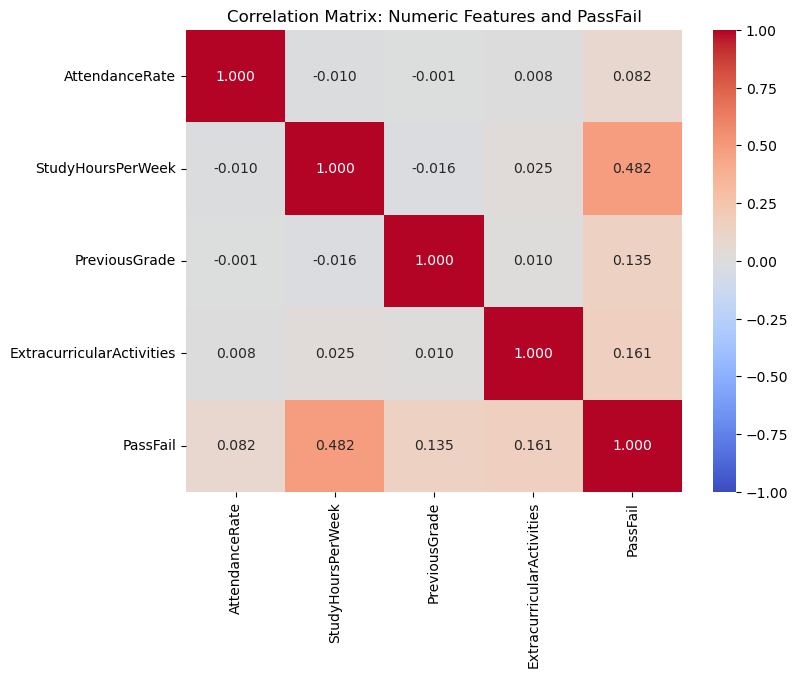

In [12]:
# Display correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    data[numeric_features + ["PassFail"]].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Numeric Features and PassFail")
plt.show()

In [15]:
#80% training, 20% testing
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.20, random_state=42, stratify=y)

print("X_train shape:", X_train_all.shape)
print("X_test shape:", X_test_all.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2083, 6)
X_test shape: (521, 6)
y_train shape: (2083,)
y_test shape: (521,)


In [19]:
#numerical variables: scale them
numeric_columns_all = ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "ExtracurricularActivities"]

#categorical variables:
categorical_columns_all = ["Gender", "ParentalSupport"]

#build data preprocessor
baseline_preprocessor = ColumnTransformer(transformers=[("numeric", StandardScaler(), numeric_columns_all),
                                               ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns_all)])

#fit preprocessing using training data
X_train_all_processed = baseline_preprocessor.fit_transform(X_train_all)

#apply the same preprocessing to unseen test data
X_test_all_processed = baseline_preprocessor.transform(X_test_all)

print("Processed training data shape:", X_train_all_processed.shape)
print("Processed testing data shape:", X_test_all_processed.shape)

Processed training data shape: (2083, 9)
Processed testing data shape: (521, 9)


In [20]:
# Create baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train using processed training data
baseline_model.fit(
    X_train_all_processed,
    y_train
)

# Predict using processed test data
baseline_prediction = baseline_model.predict(
    X_test_all_processed
)

# Calculate baseline F1-score
baseline_f1 = f1_score(
    y_test,
    baseline_prediction,
    pos_label=1,
    zero_division=0
)

print("Baseline F1-score:", round(baseline_f1, 3))

Baseline F1-score: 0.761


In [21]:
importance_results = []

for feature in candidate_features:

    # Make a copy of original unseen test data
    X_test_shuffled = X_test_all.copy()

    # Randomly shuffle only one feature
    X_test_shuffled[feature] = np.random.permutation(
        X_test_shuffled[feature].values
    )

    # Apply the already-fitted baseline preprocessor
    X_test_shuffled_processed = baseline_preprocessor.transform(
        X_test_shuffled
    )

    # Predict using the already-trained baseline model
    shuffled_prediction = baseline_model.predict(
        X_test_shuffled_processed
    )

    # Calculate F1-score after shuffling one feature
    shuffled_f1 = f1_score(
        y_test,
        shuffled_prediction,
        pos_label=1,
        zero_division=0
    )

    # Importance = decrease in F1-score
    importance = baseline_f1 - shuffled_f1

    importance_results.append({
        "Feature": feature,
        "Baseline_F1": baseline_f1,
        "Shuffled_F1": shuffled_f1,
        "F1_Decrease": importance
    })

importance_df = pd.DataFrame(
    importance_results
).sort_values(
    by="F1_Decrease",
    ascending=False
).reset_index(drop=True)

print("\nManual Feature Impact Results:")
print(importance_df.round(4))


Manual Feature Impact Results:
                     Feature  Baseline_F1  Shuffled_F1  F1_Decrease
0          StudyHoursPerWeek        0.761       0.5374       0.2236
1            ParentalSupport        0.761       0.7203       0.0407
2  ExtracurricularActivities        0.761       0.7424       0.0186
3              PreviousGrade        0.761       0.7427       0.0182
4             AttendanceRate        0.761       0.7443       0.0167
5                     Gender        0.761       0.7586       0.0024


C:\Users\Han Eswaynne\AppData\Local\Temp\ipykernel_21668\3842931208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


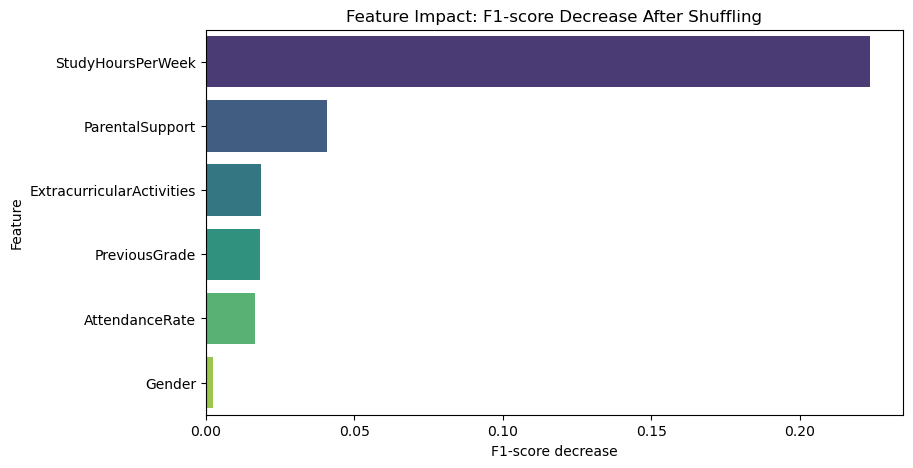

In [22]:
# Visualise feature impact
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_df,
    x="F1_Decrease",
    y="Feature",
    palette="viridis"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Feature Impact: F1-score Decrease After Shuffling")
plt.xlabel("F1-score decrease")
plt.ylabel("Feature")
plt.show()

In [24]:
importance_threshold = 0.01

important_features = importance_df.loc[
    importance_df["F1_Decrease"] > importance_threshold,
    "Feature"
].tolist()

low_impact_features = importance_df.loc[
    importance_df["F1_Decrease"] <= importance_threshold,
    "Feature"
].tolist()

print("\nFeatures to keep:")
print(important_features)

print("\nFeatures to review or possibly remove:")
print(low_impact_features)


Features to keep:
['StudyHoursPerWeek', 'ParentalSupport', 'ExtracurricularActivities', 'PreviousGrade', 'AttendanceRate']

Features to review or possibly remove:
['Gender']


In [27]:
# Temporary test: remove Gender only
selected_features = ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "ExtracurricularActivities", "ParentalSupport"]

print("Selected features for testing:")
print(selected_features)

Selected features for testing:
['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport']


In [28]:
# 1. Set selected features temporarily
selected_features = ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "ExtracurricularActivities", "ParentalSupport"]

# 2. Identify numeric and categorical selected features
selected_numeric_columns = [
    column for column in numeric_columns_all
    if column in selected_features
]

selected_categorical_columns = [
    column for column in categorical_columns_all
    if column in selected_features
]

# 3. Build preprocessor
selected_preprocessor = ColumnTransformer(transformers=[
    ("numeric", StandardScaler(), selected_numeric_columns),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        selected_categorical_columns
    )
])

# 4. Preprocess selected features
X_train_selected_processed = selected_preprocessor.fit_transform(
    X_train_all[selected_features]
)

X_test_selected_processed = selected_preprocessor.transform(
    X_test_all[selected_features]
)

# 5. Train Logistic Regression
selected_comparison_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

selected_comparison_model.fit(
    X_train_selected_processed,
    y_train
)

# 6. Predict and calculate F1-score
selected_comparison_prediction = selected_comparison_model.predict(
    X_test_selected_processed
)

selected_f1 = f1_score(
    y_test,
    selected_comparison_prediction,
    pos_label=1,
    zero_division=0
)

# 7. Compare with the all-feature model
print("All-feature baseline F1-score:", round(baseline_f1, 3))
print("Selected-feature F1-score:", round(selected_f1, 3))

All-feature baseline F1-score: 0.761
Selected-feature F1-score: 0.759


In [29]:
#since all-feature F1 score higher than selected-feature F1 score
selected_features = ["Gender", "AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "ExtracurricularActivities", "ParentalSupport"]

In [30]:
# Final X using selected features
X = data[selected_features]

# Recreate the same 80%/20% split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Identify final numerical and categorical columns
numeric_columns = [
    column for column in numeric_columns_all
    if column in selected_features
]

categorical_columns = [
    column for column in categorical_columns_all
    if column in selected_features
]

print("Final numeric columns:", numeric_columns)
print("Final categorical columns:", categorical_columns)

# Build final preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("numeric", StandardScaler(), numeric_columns),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_columns
    )
])

# Fit preprocessing using final training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply same fitted preprocessing to unseen final test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Final numeric columns: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities']
Final categorical columns: ['Gender', 'ParentalSupport']
Processed training data shape: (2083, 9)
Processed testing data shape: (521, 9)


In [31]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "Artificial Neural Network": MLPClassifier(
        hidden_layer_sizes=(50, 25),
        max_iter=2000,
        random_state=42
    )
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():

    # Train using manually processed training data
    model.fit(X_train_processed, y_train)

    # Predict using manually processed test data
    y_pred = model.predict(X_test_processed)

    # Store models and predictions
    trained_models[name] = model
    predictions[name] = y_pred

    # Calculate classification evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))


Logistic Regression
Accuracy: 0.76
Precision: 0.762
Recall: 0.76
F1-score: 0.761

K-Nearest Neighbors
Accuracy: 0.701
Precision: 0.693
Recall: 0.725
F1-score: 0.709

Support Vector Machine
Accuracy: 0.739
Precision: 0.732
Recall: 0.76
F1-score: 0.745

Artificial Neural Network
Accuracy: 0.729
Precision: 0.72
Recall: 0.756
F1-score: 0.737


In [32]:
results_df = pd.DataFrame(results)

# Highest F1-score is selected as best model
results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

print("\nModel Comparison Results:")
print(results_df.round(3))


Model Comparison Results:
                       Model  Accuracy  Precision  Recall  F1-score
0        Logistic Regression     0.760      0.762   0.760     0.761
1     Support Vector Machine     0.739      0.732   0.760     0.745
2  Artificial Neural Network     0.729      0.720   0.756     0.737
3        K-Nearest Neighbors     0.701      0.693   0.725     0.709


Best model: Logistic Regression

Confusion Matrix:
[[197  62]
 [ 63 199]]


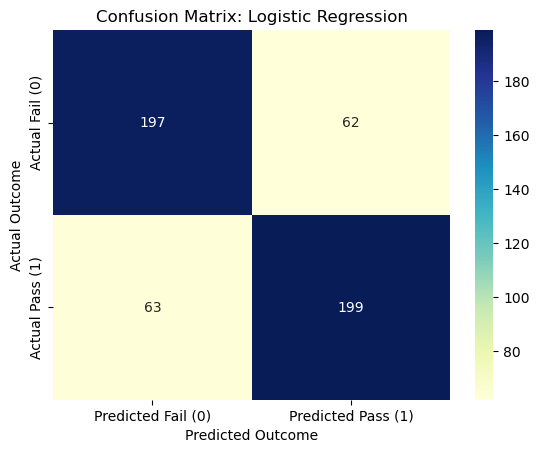

In [34]:
# Select best model
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_prediction = predictions[best_model_name]

print("Best model:", best_model_name)

# Build confusion matrix
cm = confusion_matrix(
    y_test,
    best_prediction,
    labels=[0, 1]
)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix chart
sns.heatmap(
    cm,
    xticklabels=["Predicted Fail (0)", "Predicted Pass (1)"],
    yticklabels=["Actual Fail (0)", "Actual Pass (1)"],
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [36]:
joblib.dump(
    preprocessor,
    "student_passfail_preprocessor.joblib"
)

joblib.dump(
    best_model,
    "student_passfail_best_model.joblib"
)

joblib.dump(
    selected_features,
    "student_passfail_features.joblib"
)

print("Preprocessor, best model, and selected features saved successfully.")

Preprocessor, best model, and selected features saved successfully.
